# Full Pipeline Accuracy Review

This notebook ingests the artifacts produced by `scripts/run_full_pipeline_llama_unlearn.sh` and reports the accuracies for every LLaMA/Qwen training regime.

* **Section 1** loads every `eval_result/accuracies_ckpts*.json` blob and validates that the expected checkpoints produced metrics.
* **Section 2** renders human-readable comparison tables for each model family (global + per-client).
* **Section 3** visualizes the same comparisons, grouped by benchmark.

Run each cell from the root of the FederatedScope checkout so that relative paths resolve correctly.

## 1. Data ingestion and formatting

In [29]:
import json
import re
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use('ggplot')
pd.options.display.float_format = '{:,.4f}'.format

In [30]:
FS_ROOT = Path.cwd()
PIPELINE_SCRIPT = FS_ROOT / "scripts" / "run_full_pipeline_llama_unlearn.sh"
EVAL_DIR = FS_ROOT / "eval_result"
RESULTS_DIR = FS_ROOT / "results_full"
LOG_DIR = FS_ROOT / "logs"

print(f"Repo root        : {FS_ROOT}")
print(f"Pipeline script  : {PIPELINE_SCRIPT}")
print(f"Eval artifacts   : {EVAL_DIR}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Logs directory   : {LOG_DIR}")

for path, desc in [
    (PIPELINE_SCRIPT, "pipeline script"),
    (EVAL_DIR, "eval_result directory"),
    (RESULTS_DIR, "results_full directory"),
    (LOG_DIR, "logs directory"),
]:
    if not path.exists():
        raise FileNotFoundError(f"Missing {desc}: {path}")

Repo root        : /storage/ice1/7/0/sbhansali8/FederatedScope
Pipeline script  : /storage/ice1/7/0/sbhansali8/FederatedScope/scripts/run_full_pipeline_llama_unlearn.sh
Eval artifacts   : /storage/ice1/7/0/sbhansali8/FederatedScope/eval_result
Results directory: /storage/ice1/7/0/sbhansali8/FederatedScope/results_full
Logs directory   : /storage/ice1/7/0/sbhansali8/FederatedScope/logs


In [31]:
MODEL_DIR_TO_KEY = {
    'llama2': 'llama2_composite_meta3',
    'llama2_unlearn': 'llama2_composite_meta3_unlearn',
    'llama2_unlearn_shrink05': 'llama2_composite_meta3_unlearn_shrink05',
    'qwen_moe': 'qwen15moe_composite_meta3',
    'qwen15moe': 'qwen15moe_composite_meta3',
    'qwen15moe_unlearn': 'qwen15moe_composite_meta3_unlearn',
    'qwen15moe_unlearn_shrink05': 'qwen15moe_composite_meta3_unlearn_shrink05'
}

BENCHMARK_NORMALIZATION = {
    'all_in_one': 'mmlu',
    'interleaved_all_in_one': 'mmlu',
    'gsm8k_local': 'gsm8k',
    'gsm8k': 'gsm8k',
    'code_local': 'code',
    'code': 'code',
    'instr_local': 'mmlu',
    'mmlu': 'mmlu',
    None: 'mmlu',
    '': 'mmlu'
}

BENCHMARK_LABELS = {
    'mmlu': 'MMLU',
    'gsm8k': 'GSM8K',
    'code': 'Code'
}

FAMILY_LABELS = {
    'llama2': 'LLaMA 2',
    'llama2_composite_meta3': 'LLaMA 2',
    'llama2_composite_meta3_unlearn': 'LLaMA 2',
    'llama2_composite_meta3_unlearn_shrink05': 'LLaMA 2',
    'qwen_moe': 'Qwen 1.5 MoE',
    'qwen15moe': 'Qwen 1.5 MoE',
    'qwen15moe_composite_meta3': 'Qwen 1.5 MoE',
    'qwen15moe_composite_meta3_unlearn': 'Qwen 1.5 MoE',
    'qwen15moe_composite_meta3_unlearn_shrink05': 'Qwen 1.5 MoE'
}

FAMILY_BENCHMARKS = {
    'LLaMA 2': ['mmlu', 'gsm8k', 'code'],
    'Qwen 1.5 MoE': ['mmlu', 'gsm8k', 'code']
}

CLIENT_IDS = ['client_1', 'client_2', 'client_3']
CLIENT_TITLES = [f"Client {cid.split('_')[-1]}" for cid in CLIENT_IDS]

GLOBAL_COLUMN_SPECS = [
    ('Global · Baseline (Code only)', {'scope': 'baseline', 'benchmark_raw': 'code_local'}),
    ('Global · Baseline (GSM8K only)', {'scope': 'baseline', 'benchmark_raw': 'gsm8k_local'}),
    ('Global · Baseline (Instruction only)', {'scope': 'baseline', 'benchmark_raw': 'instr_local'}),
    ('Global · Baseline (All-in-one)', {'scope': 'baseline', 'benchmark_raw': 'all_in_one'}),
    ('Global · Baseline (Interleaved)', {'scope': 'baseline', 'benchmark_raw': 'interleaved_all_in_one'}),
    ('Global · Standard FL', {'scope': 'global', 'variant': 'Standard'}),
    ('Global · Unlearn', {'scope': 'global', 'variant': 'Unlearn'}),
    ('Global · Unlearn (shrink=0.5)', {'scope': 'global', 'variant': 'Unlearn (shrink=0.5)'})
]

CLIENT_COLUMN_SPECS = []
for cid, title in zip(CLIENT_IDS, CLIENT_TITLES):
    CLIENT_COLUMN_SPECS.extend([
        (f"{title} · Standard", {'scope': 'client', 'variant': 'Standard', 'client': cid}),
        (f"{title} · Unlearn", {'scope': 'client', 'variant': 'Unlearn', 'client': cid}),
        (f"{title} · Unlearn (shrink=0.5)", {'scope': 'client', 'variant': 'Unlearn (shrink=0.5)', 'client': cid}),
    ])

CATEGORY_ORDER = ['STEM', 'humanities', 'social sciences', 'other (business, health, misc.)']

In [32]:
def infer_family(model_key: str) -> str:
    for token, label in FAMILY_LABELS.items():
        if model_key.startswith(token):
            return label
    return model_key


def infer_variant(model_key: str, scope: str, benchmark: Optional[str], client: Optional[str]) -> str:
    if scope == 'baseline':
        if benchmark == 'all_in_one':
            return 'Baseline (All-in-one)'
        if benchmark == 'interleaved_all_in_one':
            return 'Baseline (Interleaved)'
        label = benchmark.replace('_', ' ').title() if benchmark else 'Baseline'
        return f'Baseline ({label})'
    if scope == 'client':
        if 'unlearn_shrink05' in model_key:
            return 'Unlearn (shrink=0.5)'
        if 'unlearn' in model_key:
            return 'Unlearn'
        return 'Standard'
    if 'unlearn_shrink05' in model_key:
        return 'Unlearn (shrink=0.5)'
    if 'unlearn' in model_key:
        return 'Unlearn'
    return 'Standard'


def parse_accuracy_file(path: Path) -> dict:
    filename = path.name
    if not filename.startswith('accuracies_') or not filename.endswith('.json'):
        return None
    core = filename[len('accuracies_'):-5]
    benchmark_override = None
    if '__' in core:
        core, benchmark_override = core.rsplit('__', 1)
    if core.startswith('ckpts_'):
        core = core[len('ckpts_'):]
    if core.endswith('.ckpt'):
        core = core[:-5]

    raw_name = core
    scale = 'full' if raw_name.startswith('full_') else 'default'
    descriptor = raw_name[5:] if scale == 'full' else raw_name

    scope = 'global'
    model_key = descriptor
    benchmark = benchmark_override
    client = None
    lookup_key = model_key

    if descriptor.startswith('baselines_'):
        scope = 'baseline'
        rest = descriptor[len('baselines_'):]
        parts = rest.split('_', 1)
        model_key = parts[0]
        benchmark = parts[1] if len(parts) > 1 else benchmark
        lookup_key = model_key
    elif '_clients_' in descriptor:
        scope = 'client'
        model_key, client_part = descriptor.split('_clients_', 1)
        match = re.search(r'client_(\d+)', client_part)
        client = f"client_{match.group(1)}" if match else client_part
        lookup_key = model_key

    family = infer_family(model_key)
    variant = infer_variant(model_key, scope, benchmark, client)

    record = {
        'file': str(path.relative_to(FS_ROOT)),
        'raw_name': raw_name,
        'scale': scale,
        'scope': scope,
        'model_key': model_key,
        'lookup_key': lookup_key,
        'model_family': family,
        'variant': variant,
        'benchmark': benchmark,
        'client': client,
        'weighted_accuracy': None,
        'categories': {},
        'subcategories': {},
    }

    try:
        with path.open() as f:
            payload = json.load(f)
        record['weighted_accuracy'] = payload.get('weighted_accuracy')
        record['categories'] = payload.get('categories', {})
        record['subcategories'] = payload.get('subcategories', {})
    except json.JSONDecodeError as exc:
        print(f"Skipping {path}: {exc}")
        return None

    if record['benchmark'] is None:
        record['benchmark'] = ''

    record['match_key'] = (
        record['scope'],
        record['scale'],
        record['lookup_key'],
        record['benchmark'],
        record['client'] or ''
    )
    return record

records = []
for accuracy_path in sorted(EVAL_DIR.glob('accuracies_ckpts*.json')):
    record = parse_accuracy_file(accuracy_path)
    if record is not None:
        records.append(record)

if not records:
    raise RuntimeError('No accuracy files were found – rerun the evaluations.')

records_df = pd.DataFrame(records)
records_df['benchmark_norm'] = records_df['benchmark'].map(
    lambda key: BENCHMARK_NORMALIZATION.get(key, 'mmlu')
)
category_columns = sorted({k for rec in records for k in rec['categories'].keys()})
for col in category_columns:
    records_df[col] = records_df['categories'].apply(lambda d: d.get(col))

records_df = records_df.sort_values(by=['scope', 'model_family', 'variant']).reset_index(drop=True)
print(f"Loaded {len(records_df)} accuracy artifacts.")
display(records_df.head())

Loaded 41 accuracy artifacts.


,file,raw_name,scale,scope,model_key,lookup_key,model_family,variant,benchmark,client,weighted_accuracy,categories,subcategories,match_key,benchmark_norm,STEM,humanities,"other (business, health, misc.)",social sciences
0,eval_result/accuracies_ckpts_baselines_llama2_...,baselines_llama2_all_in_one,default,baseline,llama2,llama2,LLaMA 2,Baseline (All-in-one),all_in_one,None,0.4138,"{'STEM': 0.35321404903909875, 'humanities': 0....",{},"(baseline, default, llama2, all_in_one, )",mmlu,0.3532,0.3535,0.4827,0.4927
1,eval_result/accuracies_ckpts_full_baselines_ll...,full_baselines_llama2_all_in_one,full,baseline,llama2,llama2,LLaMA 2,Baseline (All-in-one),all_in_one,None,0.4116,"{'STEM': 0.36713055003313455, 'humanities': 0....",{},"(baseline, full, llama2, all_in_one, )",mmlu,0.3671,0.3424,0.4843,0.4842
2,eval_result/accuracies_ckpts_baselines_llama2_...,baselines_llama2_code_local,default,baseline,llama2,llama2,LLaMA 2,Baseline (Code Local),code_local,None,0.3722,"{'STEM': 0.3442677269715043, 'humanities': 0.3...",{},"(baseline, default, llama2, code_local, )",code,0.3443,0.3269,0.4056,0.4335
3,eval_result/accuracies_ckpts_full_baselines_ll...,full_baselines_llama2_code_local,full,baseline,llama2,llama2,LLaMA 2,Baseline (Code Local),code_local,None,0.3378,"{'STEM': 0.28793903247183567, 'humanities': 0....",{},"(baseline, full, llama2, code_local, )",code,0.2879,0.3035,0.4028,0.3708
4,eval_result/accuracies_ckpts_baselines_llama2_...,baselines_llama2_gsm8k_local,default,baseline,llama2,llama2,LLaMA 2,Baseline (Gsm8K Local),gsm8k_local,None,0.3616,"{'STEM': 0.31245858184227965, 'humanities': 0....",{},"(baseline, default, llama2, gsm8k_local, )",gsm8k,0.3125,0.3282,0.4244,0.3945


In [33]:
expected_entries = []

for dir_name, model_key in MODEL_DIR_TO_KEY.items():
  candidate = RESULTS_DIR / 'global' / dir_name
  if candidate.exists():
    for benchmark_dir in candidate.iterdir():
      if benchmark_dir.is_dir():
        expected_entries.append({
            'scope': 'global', 'scale': 'full', 'lookup_key': model_key,
            'benchmark': benchmark_dir.name, 'client': '', 'source_path': str(benchmark_dir)
        })

clients_root = RESULTS_DIR / 'clients'
if clients_root.exists():
  for dir_name, model_key in MODEL_DIR_TO_KEY.items():
    model_dir = clients_root / dir_name
    if not model_dir.exists():
      continue
    for client_dir in sorted(p for p in model_dir.iterdir() if p.is_dir()):
      expected_entries.append({
          'scope': 'client', 'scale': 'full', 'lookup_key': model_key,
          'benchmark': client_dir.name, 'client': client_dir.name, 'source_path': str(client_dir)
      })

baselines_root = RESULTS_DIR / 'baselines'
if baselines_root.exists():
  for model_dir in sorted(p for p in baselines_root.iterdir() if p.is_dir()):
    for bench_dir in sorted(p for p in model_dir.iterdir() if p.is_dir()):
      expected_entries.append({
          'scope': 'baseline', 'scale': 'full', 'lookup_key': model_dir.name,
          'benchmark': bench_dir.name, 'client': '', 'source_path': str(bench_dir)
      })

expected_df = pd.DataFrame(expected_entries)
if expected_df.empty:
  print('results_full/ is empty – no expectations could be derived.')
else:
  expected_df['match_key'] = list(zip(
      expected_df['scope'], expected_df['scale'], expected_df['lookup_key'],
      expected_df['benchmark'], expected_df['client']
  ))
  have_keys = set(records_df['match_key'])
  expected_df['present'] = expected_df['match_key'].apply(lambda key: key in have_keys)
  missing_df = expected_df[~expected_df['present']].copy()
  if missing_df.empty:
    print('All expected accuracy files are present in eval_result/.')
  else:
    print('Accuracy artifacts missing from eval_result/:')
    display(missing_df[['scope', 'lookup_key', 'benchmark', 'client', 'source_path']])

Accuracy artifacts missing from eval_result/:


,scope,lookup_key,benchmark,client,source_path
0,global,llama2_composite_meta3,gsm8k,,/storage/ice1/7/0/sbhansali8/FederatedScope/re...
1,global,llama2_composite_meta3,mmlu,,/storage/ice1/7/0/sbhansali8/FederatedScope/re...
2,global,llama2_composite_meta3,code,,/storage/ice1/7/0/sbhansali8/FederatedScope/re...
3,global,llama2_composite_meta3_unlearn,gsm8k,,/storage/ice1/7/0/sbhansali8/FederatedScope/re...
4,global,llama2_composite_meta3_unlearn,mmlu,,/storage/ice1/7/0/sbhansali8/FederatedScope/re...
5,global,llama2_composite_meta3_unlearn,code,,/storage/ice1/7/0/sbhansali8/FederatedScope/re...
6,global,llama2_composite_meta3_unlearn_shrink05,gsm8k,,/storage/ice1/7/0/sbhansali8/FederatedScope/re...
7,global,llama2_composite_meta3_unlearn_shrink05,mmlu,,/storage/ice1/7/0/sbhansali8/FederatedScope/re...
8,global,llama2_composite_meta3_unlearn_shrink05,code,,/storage/ice1/7/0/sbhansali8/FederatedScope/re...
9,global,qwen15moe_composite_meta3,gsm8k,,/storage/ice1/7/0/sbhansali8/FederatedScope/re...


## 2. Human-readable tables

In [34]:
def fetch_metric(family: str, benchmark: str, spec: dict) -> float:
    subset = records_df[
        (records_df['model_family'] == family)
        & (records_df['benchmark_norm'] == benchmark)
        & (records_df['scale'] == 'full')
    ]
    subset = subset[subset['scope'] == spec.get('scope', 'global')]
    if 'variant' in spec:
        subset = subset[subset['variant'] == spec['variant']]
    if 'client' in spec:
        subset = subset[subset['client'] == spec['client']]
    if 'benchmark_raw' in spec:
        subset = subset[subset['benchmark'] == spec['benchmark_raw']]
    if subset.empty:
        return np.nan
    return subset.iloc[0]['weighted_accuracy']


def build_family_table(family: str) -> pd.DataFrame:
    benchmarks = FAMILY_BENCHMARKS.get(family, [])
    rows = []
    missing_cells = []
    for bench in benchmarks:
        row = {'Benchmark': BENCHMARK_LABELS.get(bench, bench)}
        for label, spec in GLOBAL_COLUMN_SPECS + CLIENT_COLUMN_SPECS:
            value = fetch_metric(family, bench, spec)
            if np.isnan(value):
                missing_cells.append({'Benchmark': row['Benchmark'], 'Column': label})
            row[label] = value
        rows.append(row)
    return pd.DataFrame(rows), pd.DataFrame(missing_cells)

llama_table, llama_missing = build_family_table('LLaMA 2')
print('LLaMA 2 accuracies (global + clients):')
display(llama_table)
if not llama_missing.empty:
    print('Missing LLaMA 2 entries (these still need evaluation artifacts):')
    display(llama_missing.drop_duplicates())

qwen_table, qwen_missing = build_family_table('Qwen 1.5 MoE')
print('Qwen 1.5 MoE accuracies (global + clients):')
display(qwen_table)
if not qwen_missing.empty:
    print('Missing Qwen entries:')
    display(qwen_missing.drop_duplicates())

LLaMA 2 accuracies (global + clients):


,Benchmark,Global · Baseline (Code only),Global · Baseline (GSM8K only),Global · Baseline (Instruction only),Global · Baseline (All-in-one),Global · Baseline (Interleaved),Global · Standard FL,Global · Unlearn,Global · Unlearn (shrink=0.5),Client 1 · Standard,Client 1 · Unlearn,Client 1 · Unlearn (shrink=0.5),Client 2 · Standard,Client 2 · Unlearn,Client 2 · Unlearn (shrink=0.5),Client 3 · Standard,Client 3 · Unlearn,Client 3 · Unlearn (shrink=0.5)
0,MMLU,NaN,NaN,0.3875,0.4116,0.3628,0.2751,0.4174,0.4173,0.2294,0.3541,0.3608,0.2331,0.3424,0.3478,0.2396,0.3888,0.3837
1,GSM8K,NaN,0.3887,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Code,0.3378,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing LLaMA 2 entries (these still need evaluation artifacts):


,Benchmark,Column
0,MMLU,Global · Baseline (Code only)
1,MMLU,Global · Baseline (GSM8K only)
2,GSM8K,Global · Baseline (Code only)
3,GSM8K,Global · Baseline (Instruction only)
4,GSM8K,Global · Baseline (All-in-one)
5,GSM8K,Global · Baseline (Interleaved)
6,GSM8K,Global · Standard FL
7,GSM8K,Global · Unlearn
8,GSM8K,Global · Unlearn (shrink=0.5)
9,GSM8K,Client 1 · Standard


Qwen 1.5 MoE accuracies (global + clients):


,Benchmark,Global · Baseline (Code only),Global · Baseline (GSM8K only),Global · Baseline (Instruction only),Global · Baseline (All-in-one),Global · Baseline (Interleaved),Global · Standard FL,Global · Unlearn,Global · Unlearn (shrink=0.5),Client 1 · Standard,Client 1 · Unlearn,Client 1 · Unlearn (shrink=0.5),Client 2 · Standard,Client 2 · Unlearn,Client 2 · Unlearn (shrink=0.5),Client 3 · Standard,Client 3 · Unlearn,Client 3 · Unlearn (shrink=0.5)
0,MMLU,NaN,NaN,NaN,NaN,NaN,0.5254,NaN,NaN,0.5207,NaN,NaN,0.5169,NaN,NaN,0.5207,NaN,NaN
1,GSM8K,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Code,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing Qwen entries:


,Benchmark,Column
0,MMLU,Global · Baseline (Code only)
1,MMLU,Global · Baseline (GSM8K only)
2,MMLU,Global · Baseline (Instruction only)
3,MMLU,Global · Baseline (All-in-one)
4,MMLU,Global · Baseline (Interleaved)
5,MMLU,Global · Unlearn
6,MMLU,Global · Unlearn (shrink=0.5)
7,MMLU,Client 1 · Unlearn
8,MMLU,Client 1 · Unlearn (shrink=0.5)
9,MMLU,Client 2 · Unlearn


## 3. Graphs

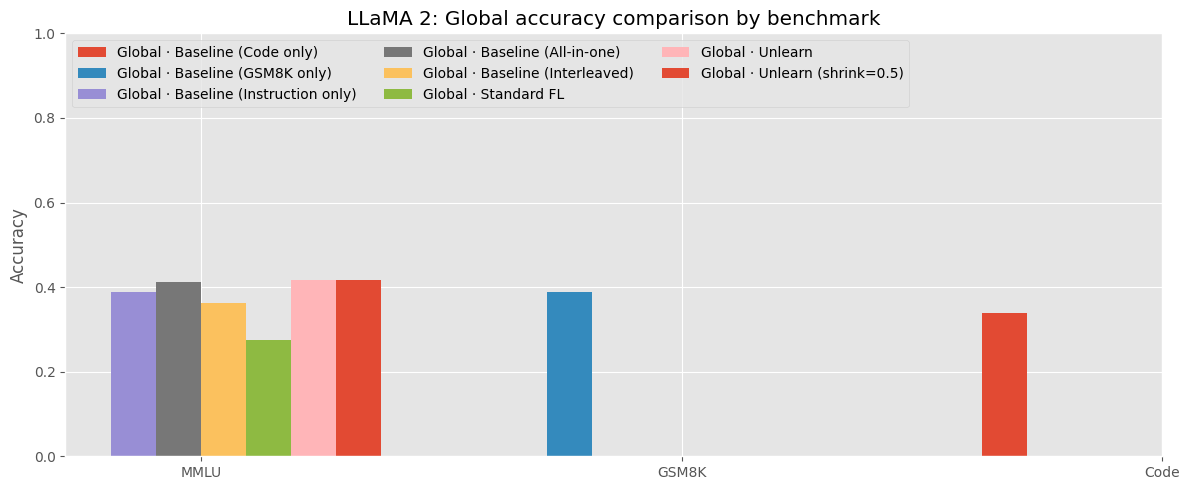

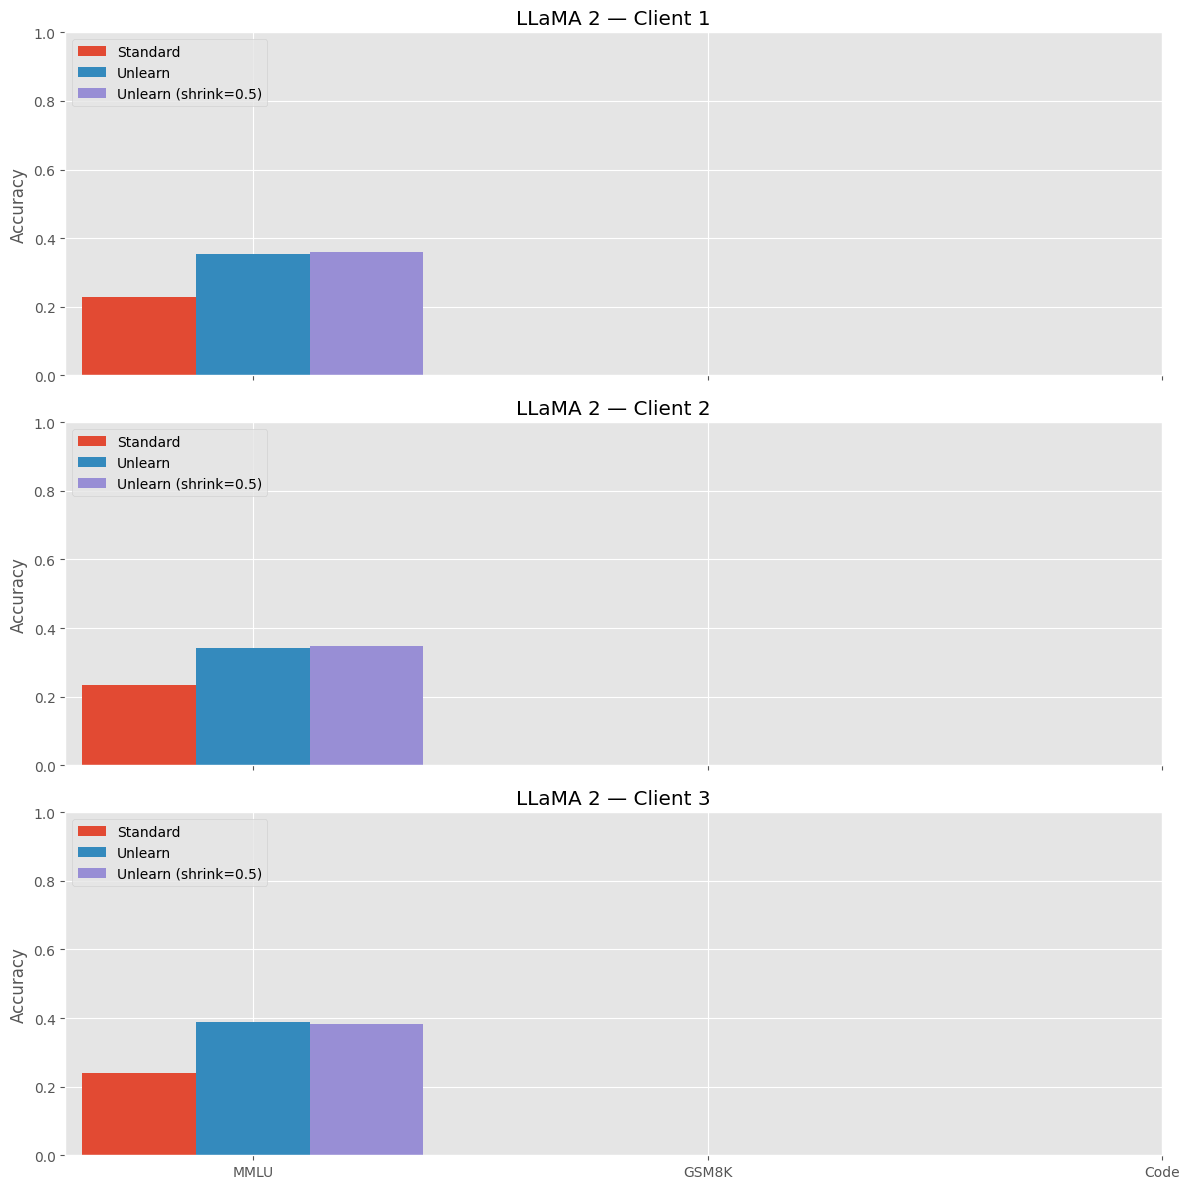

In [35]:
GLOBAL_VARIANT_ORDER = [label for label, _ in GLOBAL_COLUMN_SPECS]
CLIENT_VARIANT_GROUPS = [
    ('Standard', {'variant': 'Standard'}),
    ('Unlearn', {'variant': 'Unlearn'}),
    ('Unlearn (shrink=0.5)', {'variant': 'Unlearn (shrink=0.5)'})
]

def plot_global_benchmarks(family: str):
    benches = FAMILY_BENCHMARKS.get(family, [])
    if not benches:
        print(f'No benchmarks configured for {family}.')
        return
    data = []
    for bench in benches:
        for label, spec in GLOBAL_COLUMN_SPECS:
            value = fetch_metric(family, bench, spec)
            data.append({'Benchmark': BENCHMARK_LABELS.get(bench, bench), 'Variant': label, 'Accuracy': value})
    plot_df = pd.DataFrame(data)
    if plot_df['Accuracy'].notna().sum() == 0:
        print(f'No global accuracies available for {family}.')
        return
    benches_labels = [BENCHMARK_LABELS.get(b, b) for b in benches]
    x = np.arange(len(benches_labels))
    width = 0.75 / len(GLOBAL_VARIANT_ORDER)
    fig, ax = plt.subplots(figsize=(12, 5))
    for idx, variant in enumerate(GLOBAL_VARIANT_ORDER):
        variant_vals = []
        for bench in benches_labels:
            subset = plot_df[(plot_df['Benchmark'] == bench) & (plot_df['Variant'] == variant)]
            variant_vals.append(subset['Accuracy'].iloc[0] if not subset.empty else np.nan)
        offsets = x + (idx - (len(GLOBAL_VARIANT_ORDER) - 1) / 2) * width
        ax.bar(offsets, variant_vals, width=width, label=variant)
    ax.set_xticks(x)
    ax.set_xticklabels(benches_labels)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel('Accuracy')
    ax.set_title(f'{family}: Global accuracy comparison by benchmark')
    ax.legend(ncol=3)
    plt.tight_layout()
    plt.show()

def plot_client_benchmarks(family: str):
    benches = FAMILY_BENCHMARKS.get(family, [])
    if not benches:
        print(f'No benchmarks configured for {family}.')
        return
    benches_labels = [BENCHMARK_LABELS.get(b, b) for b in benches]
    has_data = False
    fig, axes = plt.subplots(len(CLIENT_IDS), 1, figsize=(12, 4 * len(CLIENT_IDS)), sharex=True)
    if len(CLIENT_IDS) == 1:
        axes = [axes]
    for ax, cid, title in zip(axes, CLIENT_IDS, CLIENT_TITLES):
        x = np.arange(len(benches_labels))
        width = 0.75 / len(CLIENT_VARIANT_GROUPS)
        for idx, (label, spec) in enumerate(CLIENT_VARIANT_GROUPS):
            filters = spec | {'scope': 'client', 'client': cid}
            vals = []
            for bench in benches:
                vals.append(fetch_metric(family, bench, filters))
            offsets = x + (idx - (len(CLIENT_VARIANT_GROUPS) - 1) / 2) * width
            ax.bar(offsets, vals, width=width, label=label)
            if np.any(np.isfinite(vals)):
                has_data = True
        ax.set_ylabel('Accuracy')
        ax.set_ylim(0, 1.0)
        ax.set_title(f'{family} — {title}')
        ax.legend()
    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(benches_labels)
    plt.tight_layout()
    if has_data:
        plt.show()
    else:
        plt.close(fig)
        print(f'Client accuracies unavailable for {family}.')

plot_global_benchmarks('LLaMA 2')
plot_client_benchmarks('LLaMA 2')
# plot_global_benchmarks('Qwen 1.5 MoE')
# plot_client_benchmarks('Qwen 1.5 MoE')